<div style="padding: 28px 32px; border-radius: 14px; background: linear-gradient(135deg, #172554 0%, #2563eb 52%, #14b8a6 100%); color: white; box-shadow: 0 10px 30px rgba(15, 23, 42, 0.18);">
  <p style="margin: 0 0 8px 0; font-size: 13px; letter-spacing: .08em; text-transform: uppercase; opacity: .82;">Programming Deep Learning</p>
  <h1 style="margin: 0; font-size: 34px; line-height: 1.1;">Getting to Know the Instruction Dataset (20 Min)</h1>
  <p style="margin: 14px 0 0 0; max-width: 780px; font-size: 17px; line-height: 1.55; opacity: .95;">Before training a language model, we need to understand what data it sees. This notebook helps you inspect the dataset shape, field meanings, text lengths, missing inputs, and the kinds of tasks contained in the data.</p>
</div>

### **Inspect the dataset.**

Run the cells from top to bottom. The dataset is stored locally as an Arrow file, so loading is fast and does not require downloading anything.


<span style="color:red">You need to install 'pyarrow' to your python environment for data loading.</span> 

<span style="color:red">We provided a new pyproject.toml for uv in this exercise folder.</span> 


---

## Setup

---

In [1]:
from pathlib import Path
import sys

from helper import (
    build_sample_table,
    configure_plotting,
    display_dataset_summary,
    display_example,
    display_sample_stats,
    display_prompt_preview,
    find_keyword_matches,
    interesting_example_frames,
    load_dataset,
    plot_input_presence,
    plot_length_distributions,
    resolve_dataset_path,
    show_examples,
)

%matplotlib inline
configure_plotting()
DATASET_PATH = resolve_dataset_path()


---

##  Load the dataset

---

`InstructionDataset` behaves like a PyTorch `Dataset`: `len(dataset)` gives the number of rows, and `dataset[i]` returns one Python dictionary.

In [2]:
dataset = load_dataset(DATASET_PATH)
display_dataset_summary(dataset, DATASET_PATH)


---

## Inspect one row

---

Each row has three text fields:

- `instruction`: the task the model should solve.
- `input`: extra context for the task. This field is sometimes empty.
- `output`: the answer the model should learn to produce.

In [3]:
example = dataset[0]
display_example(example, index=0)


### Quick check

Change `example_index` and rerun the cell. Try to find one example with an empty input and one with a long code answer.

In [4]:
example_index = 42
display_example(dataset[example_index], index=example_index)

---

## Analysis table

---

The full dataset is large enough that we should avoid doing expensive work repeatedly while exploring. We take a reproducible random sample and compute simple text features.

In [5]:
sample_df = build_sample_table(dataset, sample_size=5000, seed=13)
sample_df.head()


,index,instruction,input,output,has_input,instruction_chars,input_chars,output_chars,total_chars,output_lines
0,33948,Create a Visual Basic program that prompts the...,,Sub Main()\n dim user_name as String\n u...,False,100,0,120,220,6
1,38110,Complete the following SQL query to get the to...,"SELECT name, salary \nFROM employee","SELECT name, salary \nFROM employee\nORDER BY ...",True,91,34,64,189,4
2,89818,Construct an algorithm in Python that sorts an...,"myList = [3, 8, 10, 2, 4]",def quick_sort(input_list):\n if len(input_...,True,70,25,350,445,12
3,119215,Create a function in Java that takes an intege...,7,public class StarPattern {\n public static ...,True,114,1,287,402,12
4,89663,Write code for a function which will take a gi...,,def factorial(num):\n if (num == 0):\n ...,False,93,0,105,198,5


In [6]:
display_sample_stats(sample_df)


---

## Visualize Text Lengths

---

Long examples matter because they become long token sequences. Very long examples can make training slower or force truncation. We don't want to use these ...

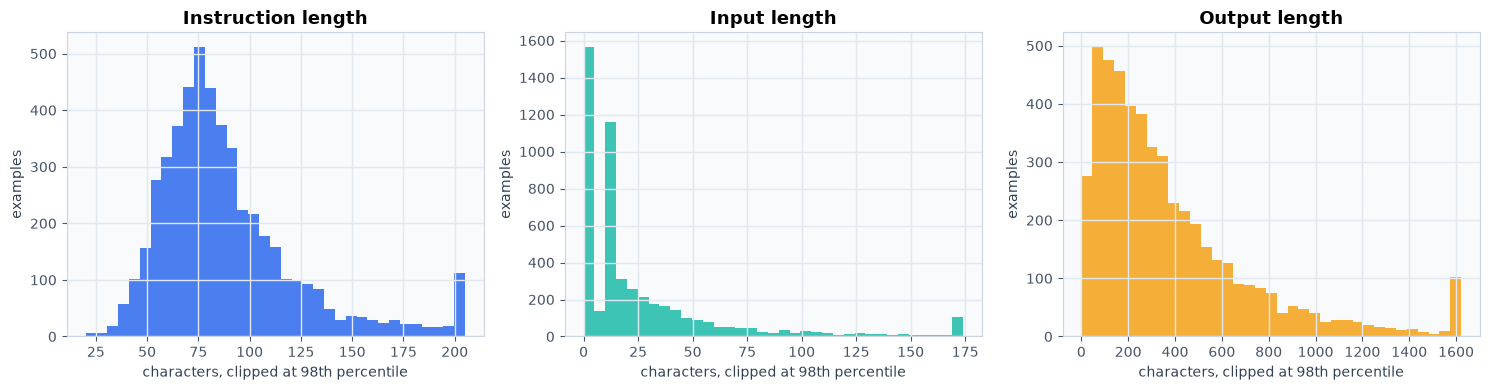

In [7]:
plot_length_distributions(sample_df)

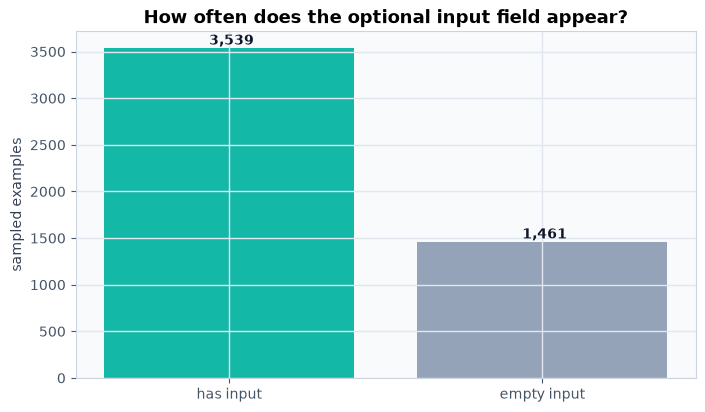

In [8]:
plot_input_presence(sample_df)


---

## Find interesting examples

---

Use the next cells like a small dataset browser. They help you look for examples that are short, long, empty-input, or input-rich.

In [9]:
frames = interesting_example_frames(sample_df)
show_examples(dataset, frames["long_outputs"], "Long output examples", n=2)


In [10]:
show_examples(dataset, frames["with_inputs"], "Examples with substantial input context", n=2)


In [11]:
show_examples(dataset, frames["without_inputs"], "Examples with empty input", n=2)


---

## How the model will see a prompt (in our training and inference)

---

Later in the exercise, the row will be turned into one training string. 

The model receives the instruction and optional input as the prompt, then learns to predict the output.

In [12]:
preview_index = 5
display_prompt_preview(dataset[preview_index], index=preview_index, max_chars=1600)

### Discussion prompts

1. Pick three examples. What makes a good instruction clear enough for a model to answer?
2. When `input` is empty, where does the missing context usually live?
3. Which examples might be hard to train on because the output is long, ambiguous, or uses a niche programming language?
4. If you had to choose a maximum sequence length, what length would you try first based on the plots?

---

## Your turn

---

Use this final cell as a sandbox. Suggested modifications:

- Change the random seed or `SAMPLE_SIZE`.
- Search for a keyword such as `SQL`, `NumPy`, `HTML`, or `JavaScript`.
- Display examples where the output has more than 20 lines.

In [13]:
keyword = "SQL"

matches = find_keyword_matches(sample_df, keyword)

show_examples(dataset, matches, f"Examples matching '{keyword}'", n=3)
